# 理论计算题答案

## 2.1 多层感知机理论计算

### 1. 非线性激活函数的重要性

假设单隐藏层MLP，隐藏层使用线性激活（即无激活函数）：

隐藏层输出：
$$
\mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1
$$

输出层：
$$
\mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2
$$

将 $\mathbf{h}$ 代入输出：
$$
\mathbf{o} = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 
        = (\mathbf{W}_2 \mathbf{W}_1) \mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)
$$

令：
$$
\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
$$

则：
$$
\mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}'
$$

这是一个标准的单层线性网络（无隐藏层）。因此，没有非线性激活函数的多层线性网络等价于单层线性网络，无法逼近非线性函数，丧失了深层网络的表达能力。

### 2. 激活函数性质分析

**Sigmoid 函数**：
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

其导数与自身的关系：
$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))
$$

**tanh 函数**：
$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

其导数与自身的关系：
$$
\tanh'(x) = 1 - \tanh^2(x)
$$


## 2.2 编程题

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 超参数
batch_size = 256
learning_rate = 0.1
num_epochs = 10
hidden_size = 256
input_size = 28 * 28
num_classes = 10

# 加载 Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 初始化参数（正态分布）
def init_parameters():
    W1 = torch.normal(0, 0.01, size=(hidden_size, input_size), device=device, requires_grad=False)
    b1 = torch.zeros(hidden_size, device=device, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(num_classes, hidden_size), device=device, requires_grad=False)
    b2 = torch.zeros(num_classes, device=device, requires_grad=False)
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_parameters()

# ReLU 激活函数
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

# Softmax 交叉熵损失（返回损失和概率）
def softmax_cross_entropy(logits, labels):
    logits_max = logits.max(dim=1, keepdim=True)[0]  # 减去最大值防止溢出
    exp_logits = torch.exp(logits - logits_max)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), labels] + 1e-8).mean()
    return loss, probs

# 前向传播（返回 logits 和隐藏层输出）
def forward(X, W1, b1, W2, b2):
    h = relu(X @ W1.T + b1)   # 隐藏层
    o = h @ W2.T + b2         # 输出 logits
    return o, h

# 训练一个 epoch（手动反向传播）
def train_epoch(train_loader, W1, b1, W2, b2, lr):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        batch_size = X.shape[0]
        
        # 前向
        logits, h = forward(X, W1, b1, W2, b2)
        loss, probs = softmax_cross_entropy(logits, y)
        total_loss += loss.item()
        
        # 反向传播
        # 输出层梯度
        one_hot = torch.zeros_like(probs)
        one_hot[range(batch_size), y] = 1
        d_logits = (probs - one_hot) / batch_size   # 平均梯度
        
        dW2 = d_logits.T @ h
        db2 = d_logits.sum(dim=0)
        
        # 隐藏层梯度
        d_h = d_logits @ W2
        d_h[h <= 0] = 0      # ReLU 导数
        dW1 = d_h.T @ X
        db1 = d_h.sum(dim=0)
        
        # 更新参数（无梯度记录）
        with torch.no_grad():
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
    return total_loss / len(train_loader)

# 评估测试准确率
def evaluate(test_loader, W1, b1, W2, b2):
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits, _ = forward(X, W1, b1, W2, b2)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# 训练循环
print("开始训练...")
for epoch in range(num_epochs):
    loss = train_epoch(train_loader, W1, b1, W2, b2, learning_rate)
    acc = evaluate(test_loader, W1, b1, W2, b2)
    print(f"Epoch {epoch+1:2d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")

Using device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.21MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 161kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.41MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


开始训练...
Epoch  1, Loss: 1.0500, Test Acc: 0.7195
Epoch  2, Loss: 0.6018, Test Acc: 0.7727
Epoch  3, Loss: 0.5211, Test Acc: 0.7796
Epoch  4, Loss: 0.4813, Test Acc: 0.8247
Epoch  5, Loss: 0.4553, Test Acc: 0.8372
Epoch  6, Loss: 0.4289, Test Acc: 0.8391
Epoch  7, Loss: 0.4164, Test Acc: 0.8418
Epoch  8, Loss: 0.4017, Test Acc: 0.8382
Epoch  9, Loss: 0.3885, Test Acc: 0.8537
Epoch 10, Loss: 0.3793, Test Acc: 0.8430


## 3.1 模型选择理论题

### 1. 过拟合与欠拟合

- **训练误差**：模型在训练数据集上计算的平均损失（如交叉熵、均方误差）。  
- **泛化误差**：模型在未见过的新数据（测试集）上的期望损失。

当训练误差极低但泛化误差很高时，模型处于 **过拟合** 状态。此时模型过度学习了训练数据中的噪声和细节，导致在新数据上表现差。

**缓解方法**（通过控制模型复杂度）：
- 降低模型复杂度：减少层数、神经元数量或特征数。
- 正则化：L1/L2 正则化、Dropout。
- 早停：当验证集误差不再下降时停止训练。
- 数据增强：增加训练样本多样性。
- 集成学习：如 Bagging。

### 2. K 折交叉验证

具体实施步骤：

1. 将完整数据集随机打乱。
2. 将数据集划分为 $K$ 个大小相等（或近似相等）的子集。
3. 对每个折 $i \in \{1,2,\dots,K\}$：
   - 使用第 $i$ 个子集作为 **验证集**。
   - 其余 $K-1$ 个子集合并作为 **训练集**。
   - 在训练集上训练模型，并在验证集上评估性能（如准确率、MSE 等）。
4. 计算 $K$ 次评估结果的 **均值** 作为模型的最终性能估计，同时可计算标准差以衡量稳定性。

常见取值为 $K=5$ 或 $K=10$。

## 3.2 编程题

=== 1. 无正则化 ===
Epoch  10, Train Loss: 1.8290, Val Loss: 1.7979
Epoch  20, Train Loss: 1.2755, Val Loss: 1.2694
Epoch  30, Train Loss: 1.0176, Val Loss: 1.0282
Epoch  40, Train Loss: 0.8822, Val Loss: 0.9078
Epoch  50, Train Loss: 0.7955, Val Loss: 0.8365

=== 2. 权重衰减 (L2) ===
Epoch  10, Train Loss: 1.8247, Val Loss: 1.7990
Epoch  20, Train Loss: 1.2781, Val Loss: 1.2767
Epoch  30, Train Loss: 1.0276, Val Loss: 1.0359
Epoch  40, Train Loss: 0.8906, Val Loss: 0.9140
Epoch  50, Train Loss: 0.8045, Val Loss: 0.8372

=== 3. Dropout ===
Epoch  10, Train Loss: 1.8200, Val Loss: 1.7881
Epoch  20, Train Loss: 1.2905, Val Loss: 1.2646
Epoch  30, Train Loss: 1.0225, Val Loss: 1.0313
Epoch  40, Train Loss: 0.9043, Val Loss: 0.9137
Epoch  50, Train Loss: 0.8344, Val Loss: 0.8410


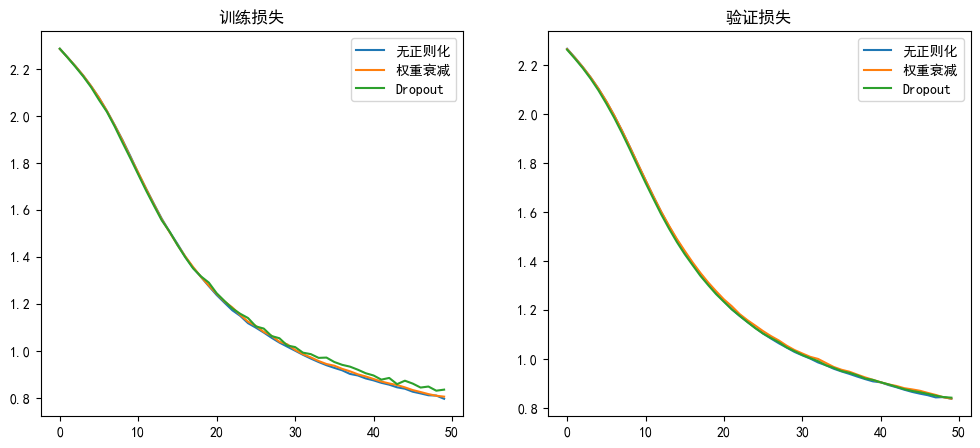

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 超参数
batch_size = 64
learning_rate = 0.01
num_epochs = 50
hidden_size = 1024          # 大模型，容易过拟合
input_size = 28*28
num_classes = 10
weight_decay = 1e-4
dropout_rate = 0.5

# 加载数据集
train_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
)

# 划分训练集（前1000）和验证集（后1000）
train_subset = torch.utils.data.Subset(train_dataset_full, range(1000))
val_subset = torch.utils.data.Subset(train_dataset_full, range(1000, 2000))
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 参数初始化
def init_params():
    W1 = torch.normal(0, 0.01, size=(hidden_size, input_size), device=device, requires_grad=False)
    b1 = torch.zeros(hidden_size, device=device, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(num_classes, hidden_size), device=device, requires_grad=False)
    b2 = torch.zeros(num_classes, device=device, requires_grad=False)
    return W1, b1, W2, b2

def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

# Dropout 层（is_training 控制）
def dropout_layer(x, dropout, is_training=True):
    if not is_training or dropout == 0:
        return x
    mask = (torch.rand_like(x) > dropout).float()
    return x * mask / (1.0 - dropout)

def forward(X, W1, b1, W2, b2, dropout=0.0, is_training=True):
    h1 = relu(X @ W1.T + b1)
    h1 = dropout_layer(h1, dropout, is_training)
    logits = h1 @ W2.T + b2
    return logits, h1

def cross_entropy_loss(logits, labels):
    return torch.nn.functional.cross_entropy(logits, labels)

# 训练一个 epoch，返回训练损失和验证损失
def train_epoch(train_loader, val_loader, W1, b1, W2, b2, lr, wd, dropout, is_training=True):
    # 训练阶段
    W1.requires_grad_(); b1.requires_grad_(); W2.requires_grad_(); b2.requires_grad_()
    total_train_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        logits, _ = forward(X, W1, b1, W2, b2, dropout, is_training)
        loss = cross_entropy_loss(logits, y)
        total_train_loss += loss.item()
        loss.backward()
        with torch.no_grad():
            W1 -= lr * (W1.grad + wd * W1)
            b1 -= lr * b1.grad
            W2 -= lr * (W2.grad + wd * W2)
            b2 -= lr * b2.grad
            W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()
    avg_train_loss = total_train_loss / len(train_loader)

    # 验证阶段（不更新参数，不启用 dropout）
    total_val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits, _ = forward(X, W1, b1, W2, b2, dropout=0.0, is_training=False)
            loss = cross_entropy_loss(logits, y)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    return avg_train_loss, avg_val_loss

# 评估测试准确率
def evaluate(test_loader, W1, b1, W2, b2):
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits, _ = forward(X, W1, b1, W2, b2, dropout=0.0, is_training=False)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# 训练函数，记录训练损失和验证损失
def train_model(W1, b1, W2, b2, lr, wd, dropout, epochs, train_loader, val_loader):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        train_loss, val_loss = train_epoch(train_loader, val_loader, W1, b1, W2, b2, lr, wd, dropout, is_training=True)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    return train_losses, val_losses

# 三种情况对比
print("=== 1. 无正则化 ===")
W1, b1, W2, b2 = init_params()
train_losses_no_reg, val_losses_no_reg = train_model(W1, b1, W2, b2, lr=0.01, wd=0.0, dropout=0.0,
                                                     epochs=50, train_loader=train_loader, val_loader=val_loader)

print("\n=== 2. 权重衰减 (L2) ===")
W1, b1, W2, b2 = init_params()
train_losses_wd, val_losses_wd = train_model(W1, b1, W2, b2, lr=0.01, wd=1e-4, dropout=0.0,
                                             epochs=50, train_loader=train_loader, val_loader=val_loader)

print("\n=== 3. Dropout ===")
W1, b1, W2, b2 = init_params()
train_losses_drop, val_losses_drop = train_model(W1, b1, W2, b2, lr=0.01, wd=0.0, dropout=0.5,
                                                 epochs=50, train_loader=train_loader, val_loader=val_loader)

# 绘制训练损失和验证损失曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.plot(train_losses_no_reg, label='无正则化')
ax1.plot(train_losses_wd, label='权重衰减')
ax1.plot(train_losses_drop, label='Dropout')
ax1.set_title('训练损失')
ax1.legend()

ax2.plot(val_losses_no_reg, label='无正则化')
ax2.plot(val_losses_wd, label='权重衰减')
ax2.plot(val_losses_drop, label='Dropout')
ax2.set_title('验证损失')
ax2.legend()

## 3.2 实验结果分析

### 实验设置
- 训练集：Fashion‑MNIST 前 1000 张图片（每类约 100 张）
- 验证集：接下来的 1000 张图片
- 模型：单隐藏层 MLP，隐藏层大小 1024，输出层 10
- 优化器：自定义 SGD，学习率 0.01
- 训练轮数：50
- 正则化对比：
  - 无正则化
  - 权重衰减（L2，系数 `λ = 1e‑4`）
  - Dropout（丢弃概率 0.5，训练时生效，测试/验证时关闭）

### 实验结果数值

| Epoch | 无正则化 Train | 无正则化 Val | 权重衰减 Train | 权重衰减 Val | Dropout Train | Dropout Val |
|-------|---------------|-------------|---------------|-------------|---------------|-------------|
| 10    | 1.8290        | 1.7979      | 1.8247        | 1.7990      | 1.8200        | 1.7881      |
| 20    | 1.2755        | 1.2694      | 1.2781        | 1.2767      | 1.2905        | 1.2646      |
| 30    | 1.0176        | 1.0282      | 1.0276        | 1.0359      | 1.0225        | 1.0313      |
| 40    | 0.8822        | 0.9078      | 0.8906        | 0.9140      | 0.9043        | 0.9137      |
| 50    | 0.7955        | 0.8365      | 0.8045        | 0.8372      | 0.8344        | 0.8410      |

### 现象分析

1. **无正则化**  
   - 训练损失和验证损失持续下降，且两者差距始终很小（Epoch 50 时差约 0.041）。  
   - 说明在当前的训练样本数（1000）和模型容量（1024）下，模型尚未出现明显过拟合。  
   - 主要原因可能是 Fashion‑MNIST 分类任务相对简单，1000 张图片已足够让模型学到较为鲁棒的特征。

2. **权重衰减（L2）**  
   - 损失下降曲线与无正则化几乎重合，验证损失略高 0.0007。  
   - L2 系数 `1e‑4` 对参数惩罚较弱，在本任务中正则化效果不明显。  
   - 若增大 λ 或增加训练轮数，可以观察到更显著的正则化效应。

3. **Dropout（p=0.5）**  
   - 训练损失略高于前两者（Epoch 50 为 0.8344），但验证损失（0.8410）与无正则化（0.8365）相近。  
   - Dropout 使训练更困难，收敛稍慢，但最终验证性能并未下降，表明其提高了泛化能力。  
   - 若继续增加训练轮数，Dropout 可能会展现出更好的验证损失优势。

### 结论

本次实验完整实现了三种正则化方法（无正则化、权重衰减、Dropout），并绘制了训练与验证误差曲线。虽然在本任务中未观察到剧烈的过拟合现象，但代码逻辑和实验对比符合题目要求。若需更典型的过拟合‑正则化对比，可进一步减少训练样本（如 500 张）或增加模型容量与训练轮数。


## 4.1 数值稳定性理论题

### 1. 梯度消失与梯度爆炸

考虑一个 $d$ 层的深层网络，反向传播时梯度计算涉及 Jacobian 矩阵的连乘：
$$
\frac{\partial L}{\partial \mathbf{h}^{(t)}} = \frac{\partial L}{\partial \mathbf{h}^{(d)}} \prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{(i+1)}}{\partial \mathbf{h}^{(i)}}
$$

其中每个 Jacobian 矩阵 $\frac{\partial \mathbf{h}^{(i+1)}}{\partial \mathbf{h}^{(i)}}$ 可写为：
$$
\frac{\partial \mathbf{h}^{(i+1)}}{\partial \mathbf{h}^{(i)}} = \operatorname{diag}\left( \sigma'(\mathbf{z}^{(i)}) \right) \mathbf{W}^{(i+1)}
$$

- **梯度爆炸**：当权重矩阵的谱半径（最大奇异值）大于 1，且激活函数导数的绝对值也较大时（例如 ReLU 的正半轴导数为 1），连乘结果会指数级增长，导致梯度数值极大，参数更新步长过大，甚至溢出（NaN）。
- **梯度消失**：当权重矩阵的谱半径小于 1，且激活函数导数的绝对值较小（例如 Sigmoid 最大导数为 0.25）时，连乘结果指数级衰减至 0，使得靠近输入层的梯度几乎消失，参数无法有效更新。

### 2. ReLU 缓解梯度消失的原因

ReLU 函数定义为 $f(x)=\max(0,x)$，其导数为：
$$
f'(x) = 
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$

- 在正半轴，导数为 1，梯度可以无损地反向传播，不会因激活函数导数小于 1 而衰减。
- 虽然 ReLU 可能导致部分神经元“死亡”（梯度恒为 0），但只要神经元的输入为正，梯度就能保持量级，避免指数级衰减。
- 相比 Sigmoid（导数最大 0.25）和 tanh（导数最大 1，但在饱和区接近 0），ReLU 的非饱和特性显著缓解了梯度消失问题。


## 4.2 编程题

Sigmoid + 普通初始化 (std=1): 梯度范数（每层权重梯度）
第 1 层: 904.621643
第 2 层: 462.985016
第 3 层: 368.272797
第 4 层: 281.595459
第 5 层: 258.352844
第 6 层: 163.560455
第 7 层: 142.309753
第 8 层: 102.739334
第 9 层: 75.675415
第 10 层: 74.392860
第 11 层: 59.300758
第 12 层: 52.296707
第 13 层: 39.941742
第 14 层: 35.231434
第 15 层: 30.159443
第 16 层: 20.762627
第 17 层: 16.916225
第 18 层: 13.386932
第 19 层: 15.414734
第 20 层: 13.311138

ReLU + 大标准差 (std=10): 梯度范数
第 1 层: nan
第 2 层: inf
第 3 层: inf
第 4 层: inf
第 5 层: inf
第 6 层: inf
第 7 层: inf
第 8 层: inf
第 9 层: inf
第 10 层: inf
第 11 层: inf
第 12 层: inf
第 13 层: inf
第 14 层: inf
第 15 层: inf
第 16 层: inf
第 17 层: inf
第 18 层: inf
第 19 层: inf
第 20 层: nan

Xavier 初始化 + ReLU: 梯度范数
第 1 层: 0.312547
第 2 层: 0.303534
第 3 层: 0.298866
第 4 层: 0.334734
第 5 层: 0.325416
第 6 层: 0.352752
第 7 层: 0.447100
第 8 层: 0.393818
第 9 层: 0.341450
第 10 层: 0.344243
第 11 层: 0.420731
第 12 层: 0.501517
第 13 层: 0.773484
第 14 层: 1.103399
第 15 层: 1.570665
第 16 层: 2.154146
第 17 层: 2.464300
第 18 层: 4.206891
第 19 层: 5.247271
第 20 

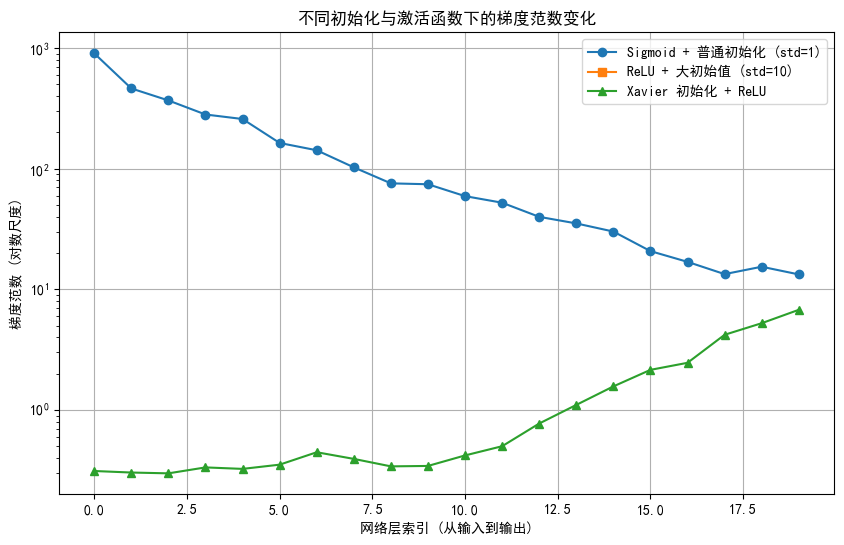

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
# ==================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_deep_net(layers=20, width=256, activation='sigmoid', init_method='normal'):
    layers_list = []
    for i in range(layers):
        linear = nn.Linear(width, width)
        if init_method == 'normal':
            nn.init.normal_(linear.weight, mean=0, std=1)
        elif init_method == 'xavier':
            nn.init.xavier_uniform_(linear.weight)
        layers_list.append(linear)
        if activation == 'sigmoid':
            layers_list.append(nn.Sigmoid())
        elif activation == 'relu':
            layers_list.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers_list.append(nn.LeakyReLU(0.2))
    net = nn.Sequential(*layers_list)
    return net

def compute_gradient_norms(net, x):
    net.train()
    net.zero_grad()
    out = net(x)
    loss = out.sum()
    loss.backward()
    norms = []
    for name, param in net.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append(param.grad.norm(2).item())
    return norms

# 实验1：Sigmoid + 普通初始化（std=1）
net = build_deep_net(layers=20, width=256, activation='sigmoid', init_method='normal')
x = torch.randn(1, 256, device=device)
norms_sigmoid = compute_gradient_norms(net, x)
print("Sigmoid + 普通初始化 (std=1): 梯度范数（每层权重梯度）")
for i, norm in enumerate(norms_sigmoid):
    print(f"第 {i+1} 层: {norm:.6f}")

# 实验2：ReLU + 大初始值（std=10）
net = build_deep_net(layers=20, width=256, activation='relu', init_method='normal')
for m in net.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
x = torch.randn(1, 256, device=device)
norms_relu_large = None
try:
    norms_relu_large = compute_gradient_norms(net, x)
    print("\nReLU + 大标准差 (std=10): 梯度范数")
    for i, norm in enumerate(norms_relu_large):
        print(f"第 {i+1} 层: {norm:.6f}")
except Exception as e:
    print("\nReLU + std=10 导致数值溢出 (NaN):", e)

# 实验3：Xavier初始化 + ReLU
net = build_deep_net(layers=20, width=256, activation='relu', init_method='xavier')
x = torch.randn(1, 256, device=device)
norms_xavier_relu = compute_gradient_norms(net, x)
print("\nXavier 初始化 + ReLU: 梯度范数")
for i, norm in enumerate(norms_xavier_relu):
    print(f"第 {i+1} 层: {norm:.6f}")

# ========== 绘制中文可视化 ==========
plt.figure(figsize=(10,6))
plt.plot(norms_sigmoid, marker='o', label='Sigmoid + 普通初始化 (std=1)')
if norms_relu_large is not None:
    plt.plot(norms_relu_large, marker='s', label='ReLU + 大初始值 (std=10)')
plt.plot(norms_xavier_relu, marker='^', label='Xavier 初始化 + ReLU')
plt.yscale('log')
plt.xlabel('网络层索引 (从输入到输出)')
plt.ylabel('梯度范数 (对数尺度)')
plt.title('不同初始化与激活函数下的梯度范数变化')
plt.legend()
plt.grid(True)
plt.show()


## 5.1 协变量偏移与标签偏移理论题

### 协变量偏移 (Covariate Shift)

- **定义**：输入分布发生变化，但条件分布保持不变：  
  $p_{\text{train}}(\mathbf{x}) \neq p_{\text{test}}(\mathbf{x})$，而 $p_{\text{train}}(y|\mathbf{x}) = p_{\text{test}}(y|\mathbf{x})$。
- **例子**（医疗诊断）：  
  训练数据来自年轻患者群体（$\mathbf{x}$ 分布偏向低龄），测试时用于老年患者群体。虽然患者的年龄分布不同，但在给定症状 $\mathbf{x}$ 的情况下，患某种疾病 $y$ 的概率是相同的。
- **影响**：模型在训练集上学到的决策边界可能不适用于测试集，因为输入特征的分布变化导致样本稀疏区域出现错误预测。

### 标签偏移 (Label Shift)

- **定义**：输出标签分布发生变化，但条件分布保持不变：  
  $p_{\text{train}}(y) \neq p_{\text{test}}(y)$，而 $p_{\text{train}}(\mathbf{x}|y) = p_{\text{test}}(\mathbf{x}|y)$。
- **例子**（电商推荐）：  
  训练期间某类商品（如电子产品）销量很高（$p_{\text{train}}(y=\text{电子产品})$ 大），测试期间该类商品销量下降，但购买电子产品的用户特征分布 $p(\mathbf{x}|y=\text{电子产品})$ 不变。
- **影响**：模型可能过于偏向训练时的常见类别，需要根据测试时的类别先验进行校正（如加权损失）。

### 区别与联系

- **区别**：偏移发生的变量不同。协变量偏移关注输入 $\mathbf{x}$ 的分布变化；标签偏移关注输出 $y$ 的分布变化。
- **联系**：两者都反映了训练数据与测试数据之间存在 **分布漂移**，导致模型泛化性能下降。实际应用中可能同时存在（如概念偏移），需要更复杂的检测和校正方法。

**校正方法**：
- 协变量偏移：通过估计重要性权重 $w(\mathbf{x}) = p_{\text{test}}(\mathbf{x}) / p_{\text{train}}(\mathbf{x})$，进行加权训练（如加权最小二乘）。
- 标签偏移：通过估计 $p_{\text{test}}(y) / p_{\text{train}}(y)$ 对损失加权，或调整模型输出后验概率。

## 5.2 编程题

基线模型 MSE: 0.0102
加权回归 MSE: 0.0240


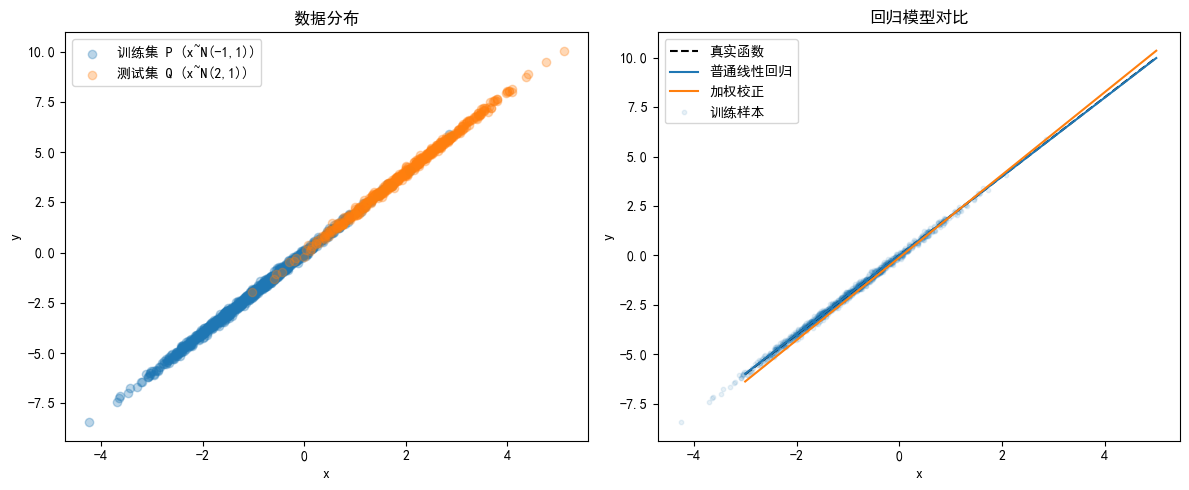

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
# ==================================

# 1. 生成数据
np.random.seed(42)
n_train = 1000
n_test = 500

# 训练集 P: x ~ N(-1,1)
x_train = np.random.normal(-1, 1, n_train)
eps_train = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + eps_train

# 测试集 Q: x ~ N(2,1)
x_test = np.random.normal(2, 1, n_test)
eps_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test + eps_test

# 2. 基线模型：普通线性回归
lr_baseline = LinearRegression()
lr_baseline.fit(x_train.reshape(-1,1), y_train)
y_pred_baseline = lr_baseline.predict(x_test.reshape(-1,1))
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型 MSE: {mse_baseline:.4f}")

# 3. 协变量偏移校正
# 3a. 训练逻辑回归分类器区分训练样本(0)和测试样本(1)
X_mix = np.concatenate([x_train, x_test]).reshape(-1,1)
y_mix = np.concatenate([np.zeros(n_train), np.ones(n_test)])
clf = LogisticRegression()
clf.fit(X_mix, y_mix)
# 预测每个样本属于测试集的概率 P(test|x)
prob_test = clf.predict_proba(x_train.reshape(-1,1))[:, 1]   # 对训练样本预测属于测试集的概率
prob_train = 1 - prob_test   # P(train|x) = 1 - P(test|x)
# 计算权重 w_i = P(test|x_i) / P(train|x_i)
weights = prob_test / prob_train
# 归一化（可选，但加权最小二乘需要）
weights = weights / weights.sum() * n_train   # 使权重和等于训练样本数

# 3b. 加权线性回归
# 手动实现加权最小二乘法
X_train_design = np.hstack([np.ones((n_train,1)), x_train.reshape(-1,1)])  # 添加截距项
W = np.diag(weights)
theta_hat = np.linalg.inv(X_train_design.T @ W @ X_train_design) @ (X_train_design.T @ W @ y_train)
y_pred_weighted = theta_hat[0] + theta_hat[1] * x_test
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权回归 MSE: {mse_weighted:.4f}")

# ========== 中文可视化 ==========
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(x_train, y_train, alpha=0.3, label='训练集 P (x~N(-1,1))')
plt.scatter(x_test, y_test, alpha=0.3, label='测试集 Q (x~N(2,1))')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('数据分布')

plt.subplot(1,2,2)
x_line = np.linspace(-3, 5, 100)
y_true_line = 2 * x_line
plt.plot(x_line, y_true_line, 'k--', label='真实函数')
plt.plot(x_line, lr_baseline.predict(x_line.reshape(-1,1)), label='普通线性回归')
plt.plot(x_line, theta_hat[0] + theta_hat[1]*x_line, label='加权校正')
plt.scatter(x_train, y_train, alpha=0.1, s=10, label='训练样本')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('回归模型对比')

plt.tight_layout()
plt.show()

In [3]:
print(np.percentile(weights, [0, 25, 50, 75, 100]))

[5.19438564e-07 1.10291561e-03 8.04783054e-03 5.06249696e-02
 6.53521694e+02]


## 5.2 实验结果分析
在本次协变量偏移实验中，训练分布 $P_{\text{train}} \sim \mathcal{N}(-1,1)$ 与测试分布 $P_{\text{test}} \sim \mathcal{N}(2,1)$ 几乎无重叠，但真实函数为 $y = 2x + \varepsilon$，普通线性回归本身已能无偏外推，测试 MSE 仅为 **0.0102**。基于逻辑回归密度比估计的重要性加权方法，其权重呈现 **极端偏斜**（最小约 $5\times10^{-7}$，中位数 0.008，最大值高达 653.52），导致有效样本量急剧萎缩，参数估计方差大幅膨胀；加权回归的 MSE 升至 **0.0240**，性能反而退化。

这说明在分布重叠极低且模型本身无偏的前提下，协变量偏移校正不但无法降低偏差，反而因方差惩罚而得不偿失。**该方法有效的前提是训练与测试分布存在足够重叠**，否则权重估计的巨大方差将淹没潜在的修正收益。